In [1]:
# Data manipulation libraries
import pandas as pd
import numpy as np

# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting, transforming and model training libraries
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler  

# Import Warnings
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Setting Configurations
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [3]:
# Dataset import
df = pd.read_csv('Dataset_churn.csv')

In [4]:
# Let's look at the first 5 observations of the dataset.
print(df.head())

   CustomerID  Age  Gender  Tenure  MonthlyCharges        Contract     PaymentMethod  TotalCharges Churn
0           1   56  Female      68         147.580        Two year     Bank transfer     10052.030    No
1           2   69    Male      32          22.540  Month-to-month      Mailed check       686.780    No
2           3   46  Female      10          52.470        One year  Electronic check       537.880    No
3           4   32    Male      22         109.670  Month-to-month      Mailed check      2390.040   Yes
4           5   60  Female      54         130.980  Month-to-month       Credit card      7081.280    No


In [5]:
# Let's look at the summary statistics of the dataset.
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  str    
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  str    
 6   PaymentMethod   100000 non-null  str    
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  str    
dtypes: float64(2), int64(3), str(4)
memory usage: 6.9 MB
None


In [6]:
# Statistical summary of the dataset
print(df.describe())

       CustomerID        Age     Tenure  MonthlyCharges  TotalCharges
count  100000.000 100000.000 100000.000      100000.000    100000.000
mean    50000.500     49.027     36.527          79.975      2926.140
std     28867.658     18.178     20.790          40.492      2388.164
min         1.000     18.000      1.000          10.000      -118.430
25%     25000.750     33.000     18.000          44.720       963.668
50%     50000.500     49.000     37.000          80.000      2268.060
75%     75000.250     65.000     54.000         115.050      4394.327
max    100000.000     80.000     72.000         150.000     10831.460


In [7]:
# Checking for missing values
print(df.isnull().sum())

CustomerID        0
Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64


In [8]:
#Target variable distribution
print(df['Churn'].value_counts(normalize=True)*100)

Churn
No    66.856
Yes   33.144
Name: proportion, dtype: float64


In [9]:
# Again checking for missing values
df.isnull().sum()

CustomerID        0
Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64

In [10]:
# The "TotalCharges" Trap -> Convert it from string to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

In [11]:
# The model needs numbers, not text.
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [12]:
# Using drop_first = True to avoid dummy variable trap and cleaner model.
df = pd.get_dummies(df, drop_first=True)

In [17]:
# Feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_cols = ["Tenure","MonthlyCharges","TotalCharges"]
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [19]:
# Let's start with the Feature selection process.
df = df.drop("CustomerID", axis=1)

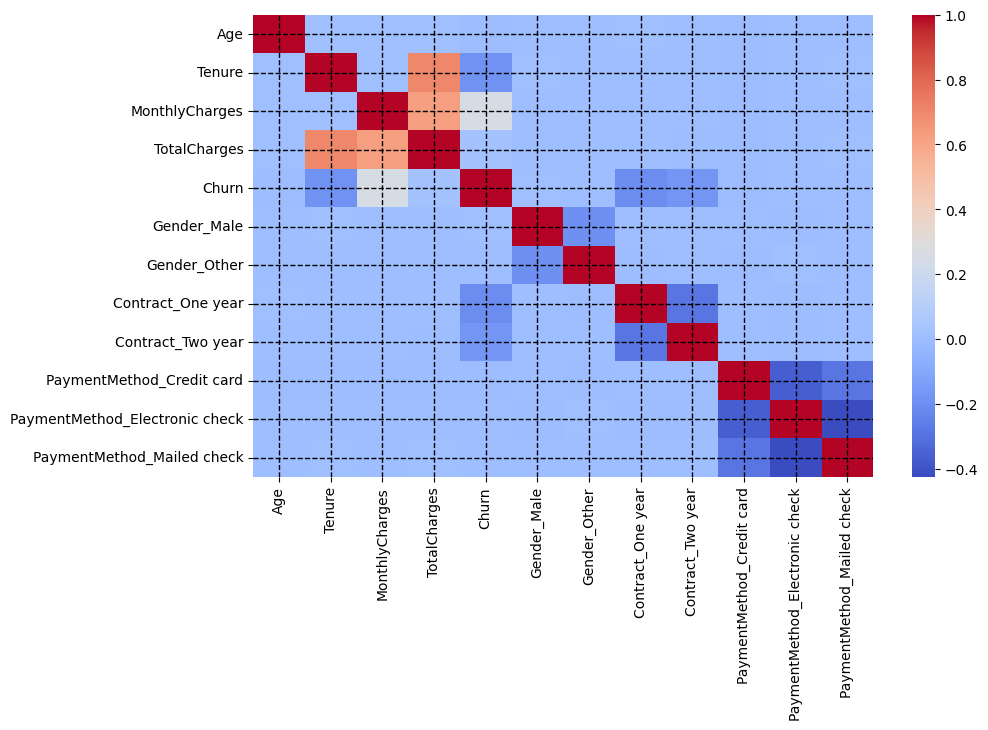

In [30]:
# Quick EDA to check the correlation of features with the target variable
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.grid( True, linestyle='--', linewidth=1, c="black")
plt.show()

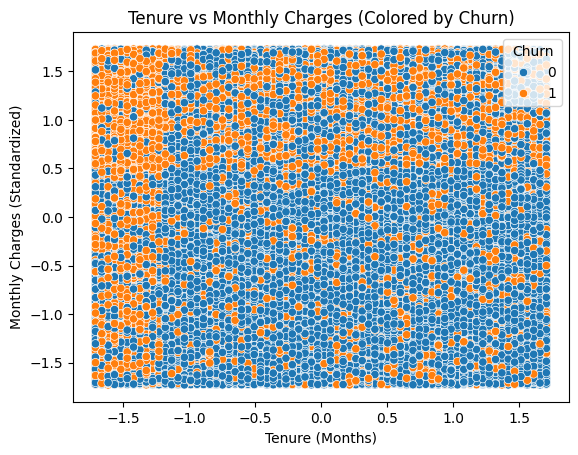

In [31]:
# let's use scatter plot to check the correlation of numeric features with the target variable
sns.scatterplot(x='Tenure', y="MonthlyCharges", hue="Churn", data=df)
plt.title('Tenure vs Monthly Charges (Colored by Churn)')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges (Standardized)')
plt.show()

## Shows you how that relationship looks.
### For example, you might see that customers with low tenure and high monthly charges are the ones most likely to churn (the orange dots).

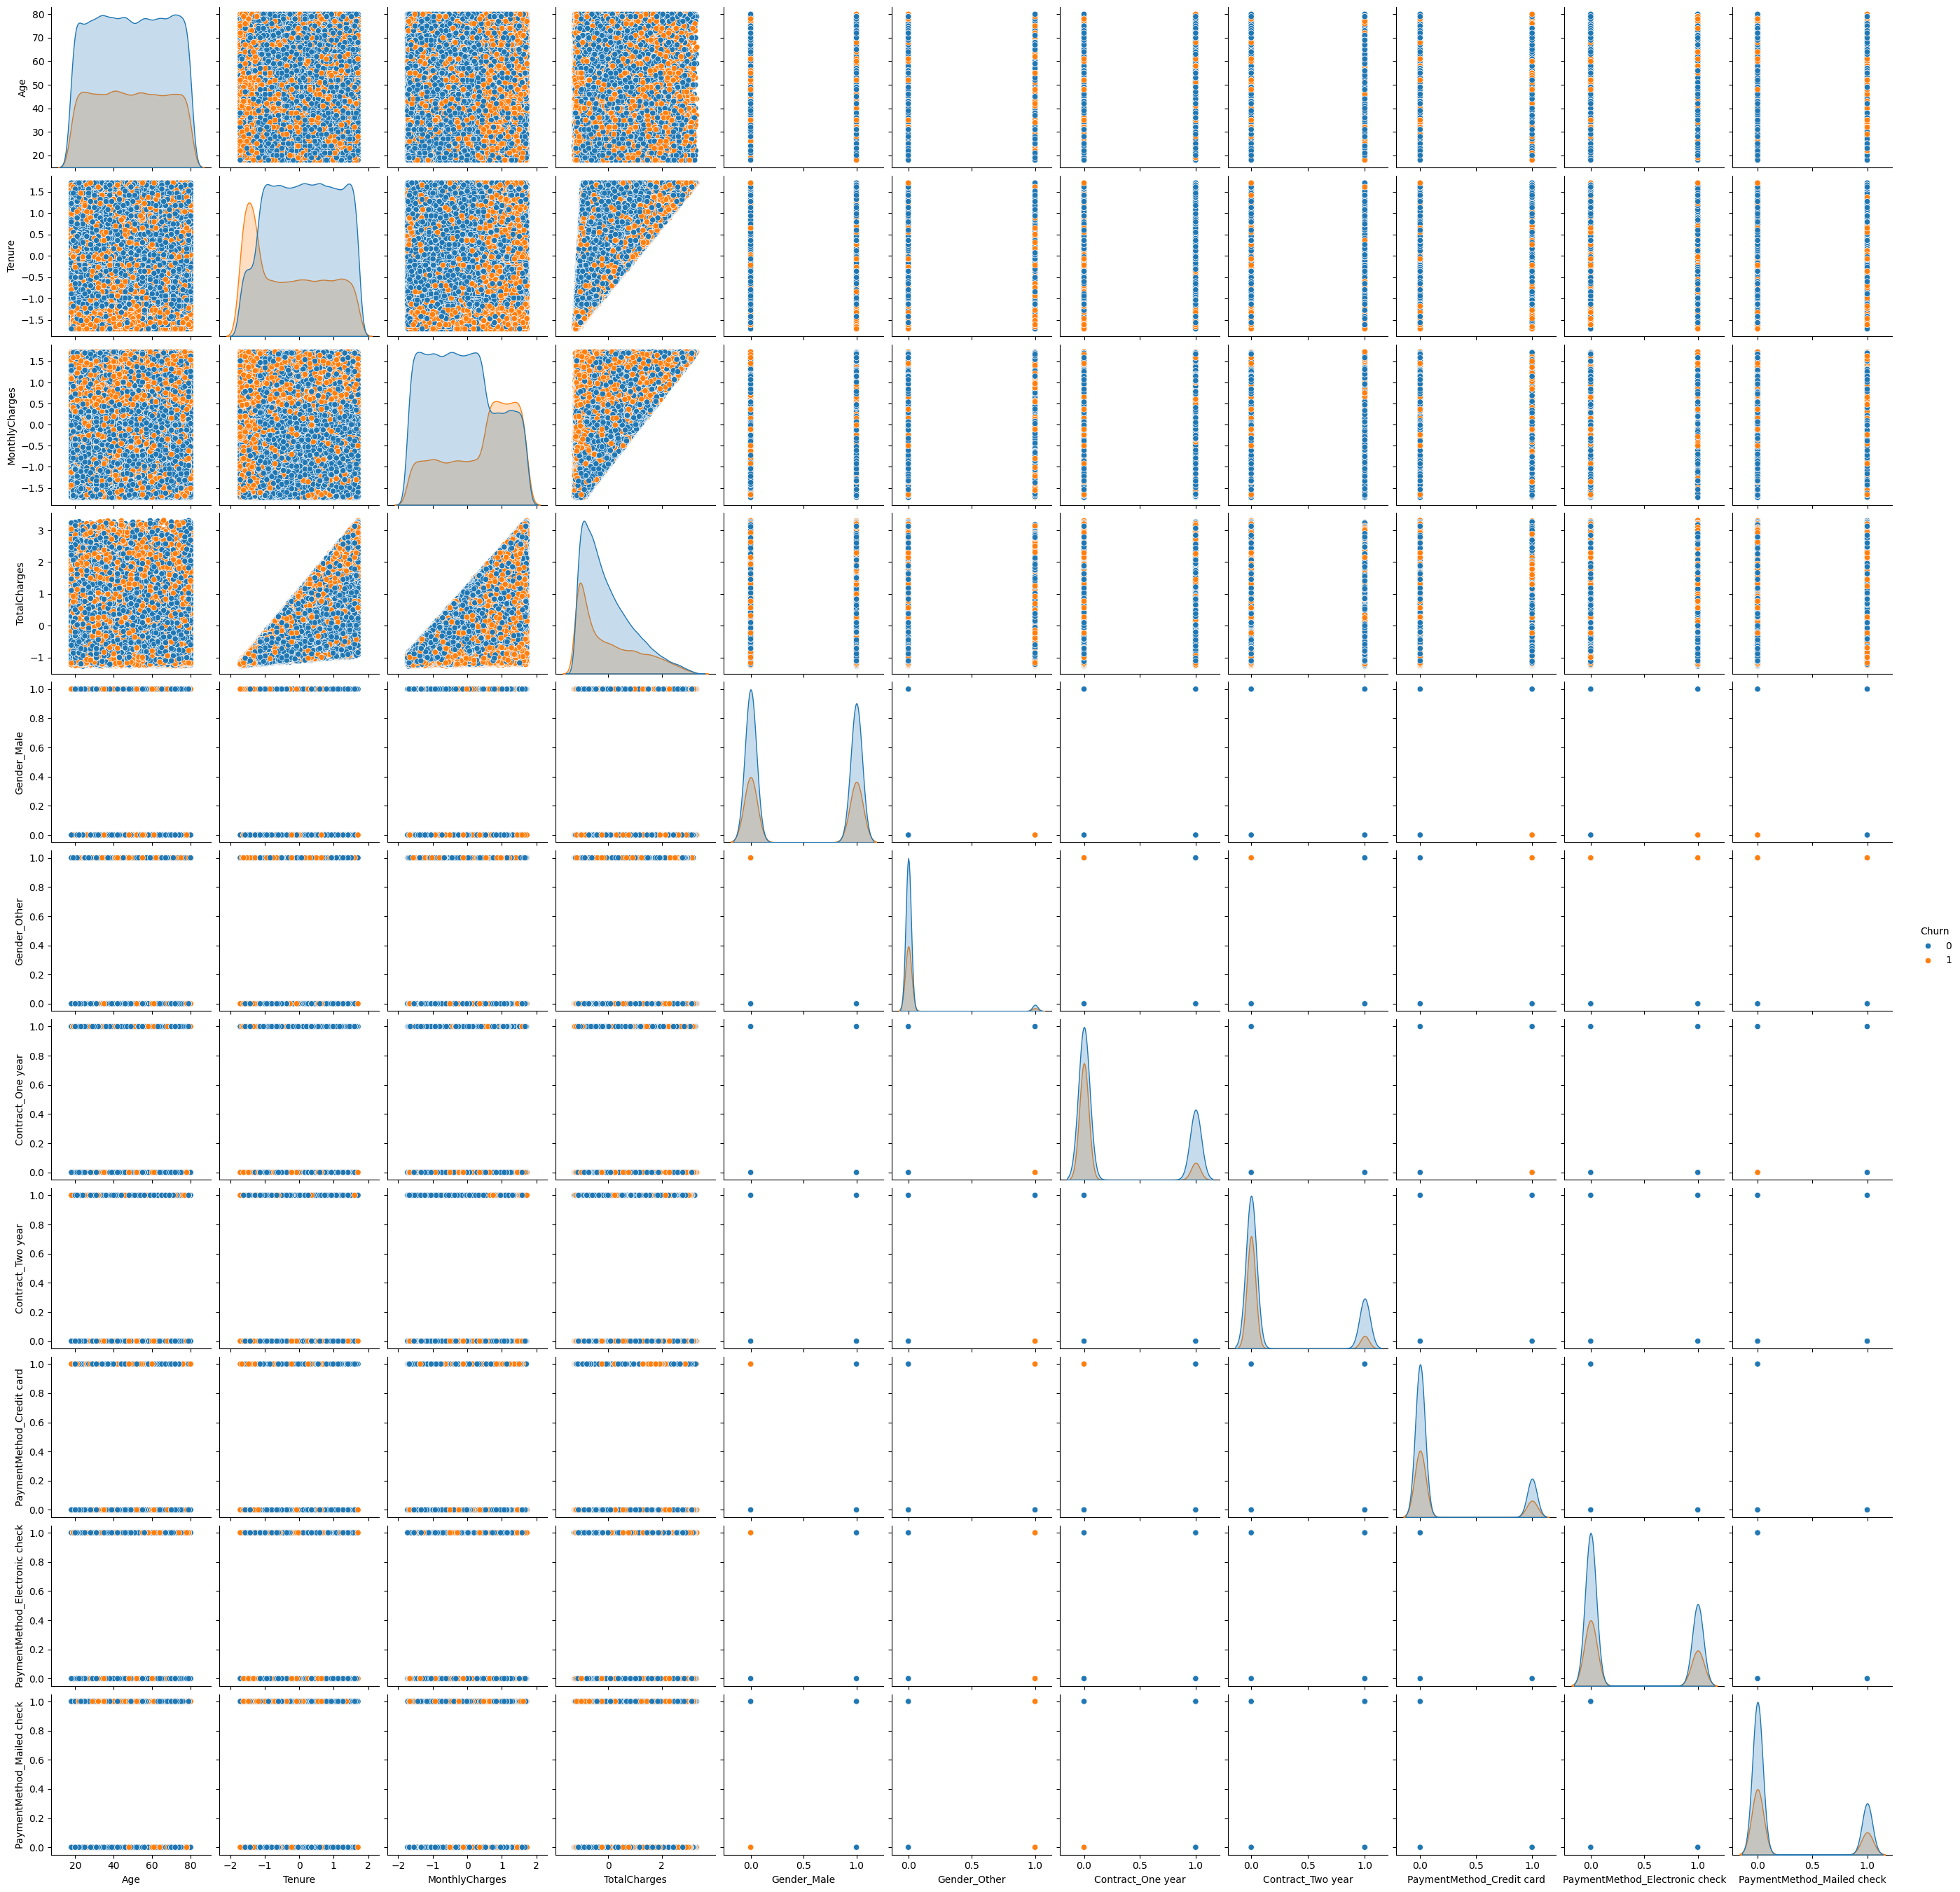

In [32]:
# Lets check all the relationships at once using pairplot
sns.pairplot(df, hue="Churn")
plt.show()

### This comes handy is you need something to take as a reference for model building.